# Stage 7 — Visualization

Final plots that feed the project write-up.

## Outputs (written to `./results/`)
- `accuracy_time_plots.png` — 2×2 grid: NLP F1 vs train time, regression R²
  vs train time, NLP train/infer time bars, regression baseline-vs-+NLP bars.
- `nlp_pareto.png` — NLP Pareto frontier (F1 vs train time).
- `regression_pareto.png` — Regression Pareto frontier (R² vs train time).
- `experiment_config.json` — full config snapshot for reproducibility.

## Why "train_time_s" not "energy_train_kwh" yet
The frontier plots currently use `train_time_s` as the x-axis (cost). Once
the external energy log is joined onto the per-run CSVs, the same plots
become the **central deliverable of the thesis** by changing one argument:
swap `x_col="train_time_s"` for `x_col="energy_train_kwh"` and the time-cost
frontier becomes the energy-cost frontier. The structural plot is identical;
only the units on the x-axis change.

## What this stage consumes
- `./results/nlp_results.csv` (Stage 3).
- `./results/regression_results.csv` (Stage 4).
- `./results/inference_results.csv` (Stage 5, optional).


In [1]:
# Shared config, paths, and utility imports.
from common import *

# Plotting libraries for final project figures.
import matplotlib.pyplot as plt
import seaborn as sns

# Match visual style used in Stage 6.
sns.set_theme(style="whitegrid")

# Load summary results generated by prior stages.
nlp_df = pd.read_csv(RESULTS_DIR / "nlp_results_with_energy.csv")
reg_df = pd.read_csv(RESULTS_DIR / "regression_results.csv")

# Inference file may not exist if Stage 5 was skipped.
inf_path = RESULTS_DIR / "inference_results.csv"
inf_df = pd.read_csv(inf_path) if inf_path.exists() else None

[common] device=cpu  artifacts=/cluster/tufts/hrilab/jmonta04/modular_pipeline/artifacts  results=/cluster/tufts/hrilab/jmonta04/modular_pipeline/results


## 7.1 Accuracy vs time — 2×2 grid

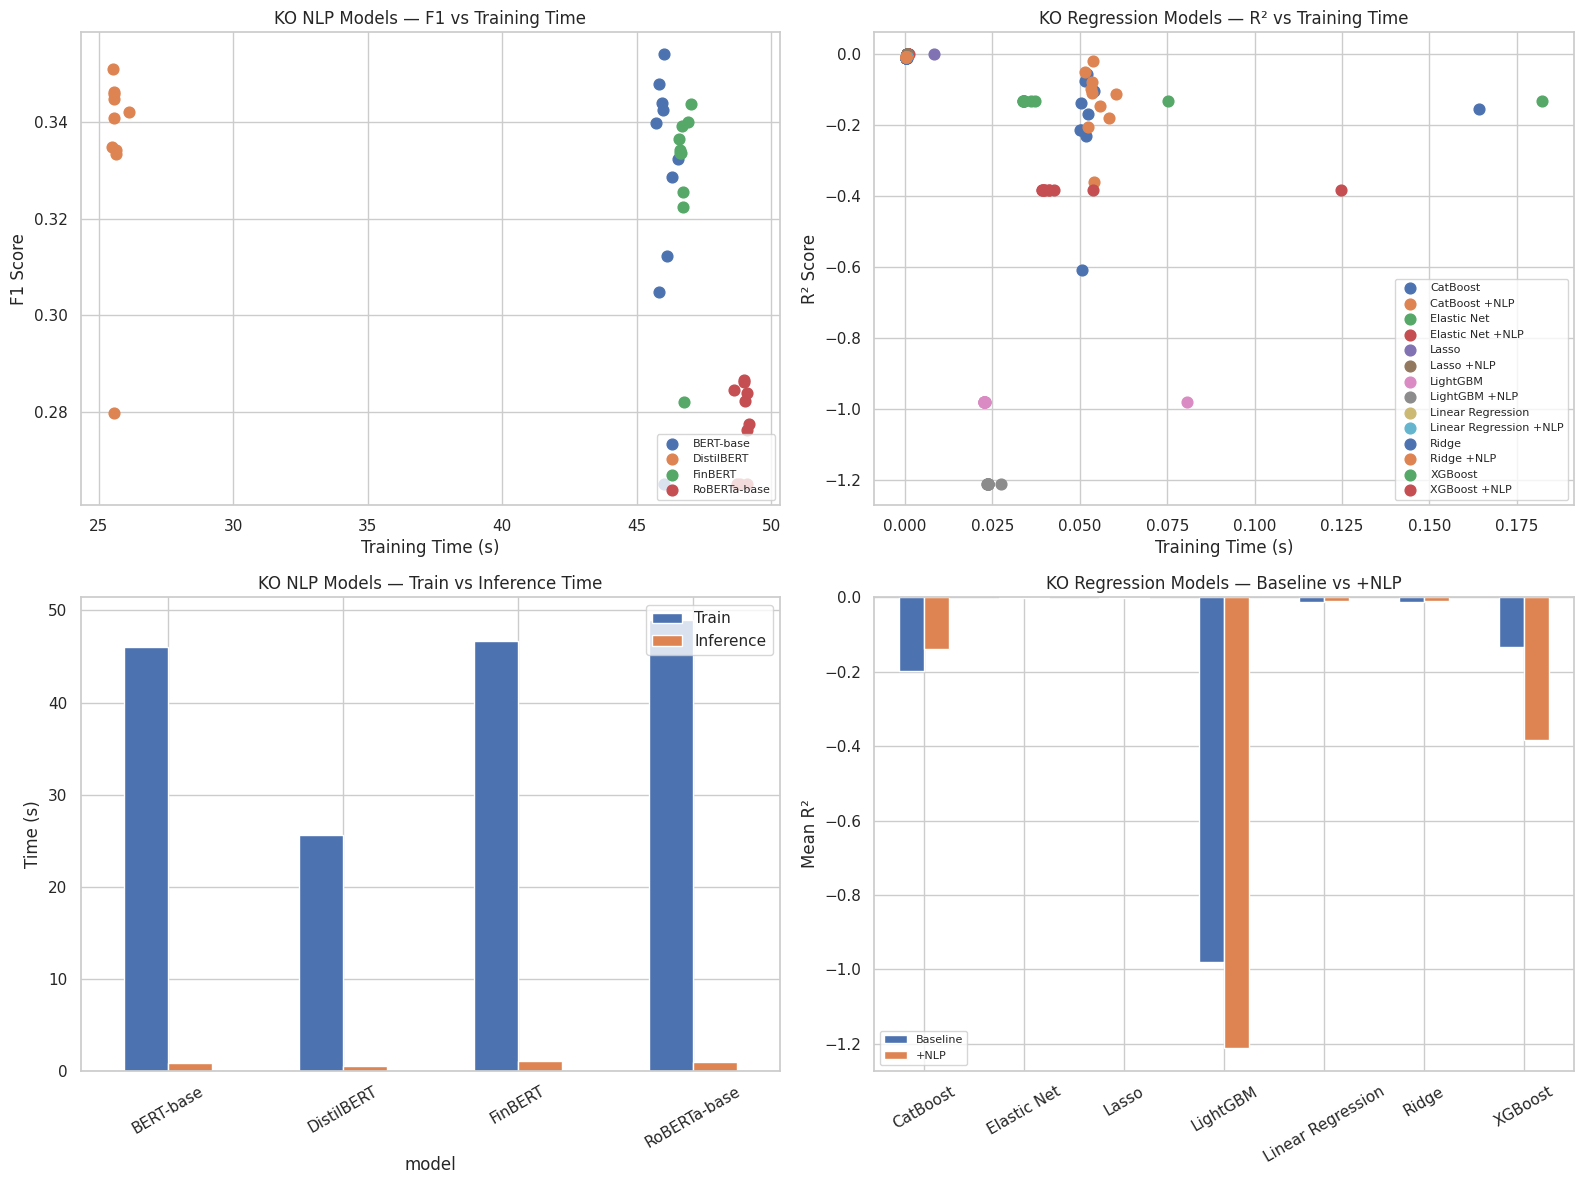

Saved /cluster/tufts/hrilab/jmonta04/modular_pipeline/results/accuracy_time_plots.png


In [2]:
# 2x2 panel of summary plots:
#   (0,0): NLP F1 vs training time — one dot per (model, seed). Cluster
#          tightness indicates seed stability per model.
#   (0,1): Regression R² vs training time, both baseline and +NLP variants.
#   (1,0): Mean train vs inference time per NLP model — relative cost shape.
#   (1,1): Per-regressor baseline vs +NLP R² — visualizes Stage 4's uplift.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) NLP scatter: F1 versus training time.
ax = axes[0, 0]
for model_name, grp in nlp_df.groupby("model"):
    ax.scatter(grp["train_time_s"], grp["f1"], label=model_name, s=60)
ax.set_xlabel("Training Time (s)")
ax.set_ylabel("F1 Score")
ax.set_title("KO NLP Models — F1 vs Training Time")
ax.legend(fontsize=8, loc="lower right")

# 2) Regression scatter: R² versus training time.
ax = axes[0, 1]
for model_name, grp in reg_df.groupby("model"):
    ax.scatter(grp["train_time_s"], grp["r2"], label=model_name, s=60)
ax.set_xlabel("Training Time (s)")
ax.set_ylabel("R² Score")
ax.set_title("KO Regression Models — R² vs Training Time")
ax.legend(fontsize=8, loc="lower right")

# 3) NLP bar chart: mean train and inference time per model.
ax = axes[1, 0]
nlp_agg = nlp_df.groupby("model")[["train_time_s", "infer_time_s"]].mean()
nlp_agg.plot.bar(ax=ax)
ax.set_ylabel("Time (s)")
ax.set_title("KO NLP Models — Train vs Inference Time")
ax.tick_params(axis="x", rotation=30)
ax.legend(["Train", "Inference"])

# 4) Regression bar chart: baseline R² compared to +NLP R².
ax = axes[1, 1]
baseline_mean = reg_df[~reg_df["model"].str.endswith("+NLP")].groupby("model")["r2"].mean()
aug_mean = reg_df[reg_df["model"].str.endswith("+NLP")].assign(
    base_model=lambda d: d["model"].str.replace(" +NLP", "", regex=False)
).groupby("base_model")["r2"].mean()
compare_r2 = pd.concat(
    [baseline_mean.rename("Baseline"), aug_mean.rename("+NLP")], axis=1
)
compare_r2.plot.bar(ax=ax)
ax.set_ylabel("Mean R²")
ax.set_title("KO Regression Models — Baseline vs +NLP")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=8)

# Save and show final 2x2 figure.
plt.tight_layout()
plt.savefig(RESULTS_DIR / "accuracy_time_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {RESULTS_DIR / 'accuracy_time_plots.png'}")

## 7.2 Pareto frontiers

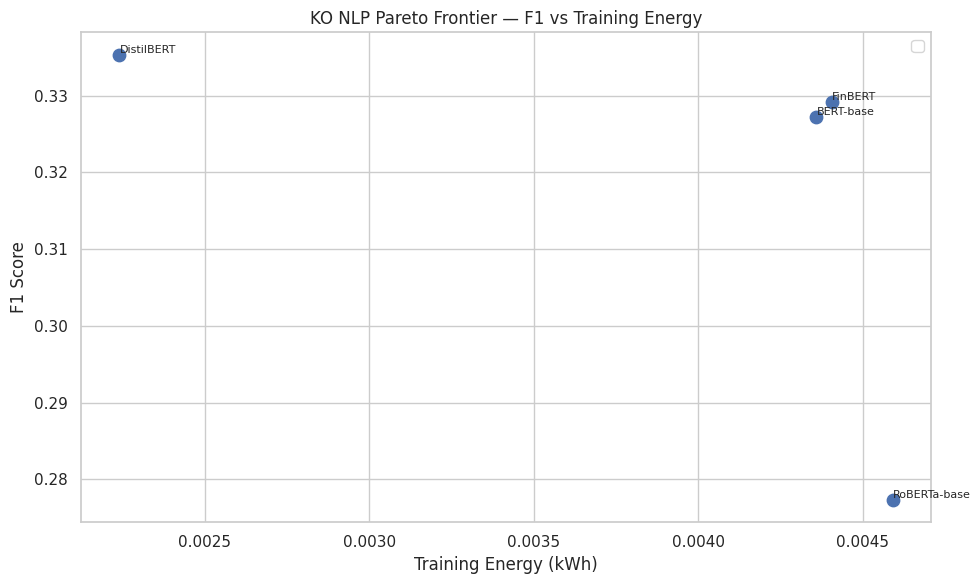

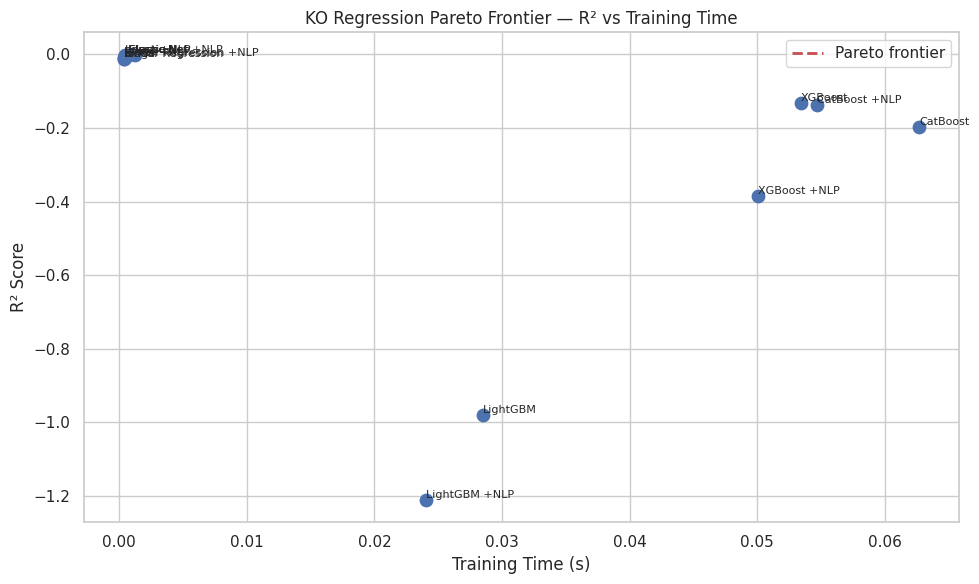

In [3]:
def plot_pareto(df, x_col, y_col, title, xlabel, ylabel, save_as=None):
    """Plot model averages and highlight Pareto-optimal frontier points."""
    # Pareto-frontier construction (lower x is better, higher y is better):
    #
    #   1. Collapse per-seed runs to one mean point per model. Each model
    #      becomes a single (cost, accuracy) coordinate.
    #   2. Sort points left-to-right by x (cost ascending).
    #   3. Walk the sorted list once. Keep a running `best_y`; admit a point
    #      to the frontier only if its y improves over best_y so far.
    #   4. The kept points form the upper-left envelope: the set of models
    #      for which no other model is BOTH cheaper AND more accurate.
    #
    # Models that fall below this envelope are "dominated" — there exists
    # some other model that beats them on both axes simultaneously, so they
    # are never the right choice regardless of how cost and accuracy are
    # weighted against each other.
    # Collapse per-seed runs to one mean point per model.
    agg = df.groupby("model").agg(
        x_mean=(x_col, "mean"),
        y_mean=(y_col, "mean"),
    ).reset_index()

    # Sort by x-axis (cost) so we can build the frontier left-to-right.
    sorted_pts = agg.sort_values("x_mean")
    pareto_x, pareto_y = [], []
    best_y = -np.inf
    for _, row in sorted_pts.iterrows():
        # Keep only points that improve y over all cheaper points.
        if row["y_mean"] > best_y:
            pareto_x.append(row["x_mean"])
            pareto_y.append(row["y_mean"])
            best_y = row["y_mean"]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(agg["x_mean"], agg["y_mean"], s=80, zorder=3)

    # Annotate each point with model name to keep chart self-explanatory.
    for _, row in agg.iterrows():
        ax.annotate(
            row["model"],
            (row["x_mean"], row["y_mean"]),
            fontsize=8,
            ha="left",
            va="bottom",
        )

    # Draw the frontier line only if we have multiple frontier points.
    if len(pareto_x) > 1:
        ax.plot(pareto_x, pareto_y, "r--", linewidth=2, label="Pareto frontier")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

    plt.tight_layout()
    if save_as:
        plt.savefig(RESULTS_DIR / save_as, dpi=150, bbox_inches="tight")
    plt.show()


# Pareto frontier for NLP model tradeoff.
plot_pareto(
    nlp_df,
    "energy_train_kwh",
    "f1",
    "KO NLP Pareto Frontier — F1 vs Training Energy",
    "Training Energy (kWh)",
    "F1 Score",
    save_as="nlp_pareto.png",
)

# Pareto frontier for regression model tradeoff.
plot_pareto(
    reg_df,
    "train_time_s",
    "r2",
    "KO Regression Pareto Frontier — R² vs Training Time",
    "Training Time (s)",
    "R² Score",
    save_as="regression_pareto.png",
)

## 7.3 Experiment summary

In [4]:
# Reproducibility deliverable: a single JSON snapshot of every config knob
# and registry used to produce the figures above. Together with the artifact
# parquet files in ./artifacts/ and the per-run CSVs in ./results/, this
# JSON is sufficient for a reader to know exactly which models, seeds,
# hyperparameters, and lambda regimes were in scope when these plots were
# generated. Recommend committing it alongside any plot included in the writeup.
summary = {
    # Full configuration snapshot used for this run.
    "config": CONFIG,
    # Model names included in each stage.
    "nlp_models": list(NLP_MODELS.keys()),
    "regression_models": list(REGRESSION_MODELS.keys()),
    # Hardware device used for execution.
    "device": str(DEVICE),
    # Row counts of saved results tables.
    "counts": {
        "nlp_runs": int(len(nlp_df)),
        "regression_runs": int(len(reg_df)),
        "inference_runs": int(len(inf_df)) if inf_df is not None else 0,
    },
}

# Write summary JSON to results directory.
with open(RESULTS_DIR / "experiment_config.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print(f"NLP runs:        {summary['counts']['nlp_runs']}")
print(f"Regression runs: {summary['counts']['regression_runs']}")
print(f"Inference runs:  {summary['counts']['inference_runs']}")
print(f"Summary written to {RESULTS_DIR / 'experiment_config.json'}")

NLP runs:        40
Regression runs: 140
Inference runs:  4
Summary written to /cluster/tufts/hrilab/jmonta04/modular_pipeline/results/experiment_config.json
